In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# Merge AI Skills

In [2]:
jobs_path = "../data/OII_US_10M_POSTS_V2.csv"

In [3]:
# processed data from thesis with AI skills labels
p_data = pd.read_parquet('/data/sant6443/thesis/data/us_10m_wham_nointernship_2019_2023.parquet.gzip')

In [4]:
all_data = pd.read_csv(jobs_path)

In [5]:
all_data = all_data[all_data['IS_INTERNSHIP']==False]

In [6]:
p_data = p_data[['ID','Has AI Skills', 'wfh_wham_prob', 'wfh_wham']]

In [7]:
all_data = all_data.merge(p_data, left_on='ID', right_on='ID', how='left')

In [8]:
all_data.groupby('Has AI Skills', dropna = False).size()

Has AI Skills
False    9810164
True      133852
NaN      1637310
dtype: int64

In [9]:
all_data['YEAR'] = pd.to_datetime(all_data['POSTED']).dt.year

In [10]:
all_data.groupby('YEAR').size()

YEAR
2018    1637310
2019    1704282
2020    1735298
2021    2164896
2022    2402338
2023    1937202
dtype: int64

In [12]:
all_data[all_data['Has AI Skills'].isnull()].groupby('YEAR').size()

YEAR
2018    1637310
dtype: int64

In [9]:
len(all_data)

11581326

In [11]:
pd.set_option('display.max_columns', None)

In [12]:
all_data.head()

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,Has AI Skills,wfh_wham_prob,wfh_wham,YEAR
0,b5e9360ab429758bc6e8e259fcf66234d3163dcf,"Brentwood, TN","Williamson, TN",Tennessee,62,Health Care and Social Assistance,Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121Z26S4VJLQ1WXN21"",\n ""KS7G4YT72YHJ3...","[\n ""Customer Service"",\n ""Collections"",\n ...",2019-12-05,2024-03-26,29-1051.00,Pharmacists,29-1051.00,Pharmacists,Healthcare Practitioners and Technical Occupat...,29-0000,8.0,47183298,Premise Health,Premise Health,False,0.001,0.0,2019
1,eff8c5c87b50735a4684ebc33d41d1b36ff46aa8,"Smyrna, TN","Rutherford, TN",Tennessee,72,Accommodation and Food Services,High school or GED,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS126DB6T061MHD7RTGQ"",\n ""KS121Z26S4VJL...","[\n ""Merchandising"",\n ""Customer Service"",\n...",2019-12-05,2023-11-03,37-2011.00,"Janitors and Cleaners, Except Maids and Housek...",37-2011.00,"Janitors and Cleaners, Except Maids and Housek...",Building and Grounds Cleaning and Maintenance ...,37-0000,NaN,40582235,Carrols Corporation,Carrols Corporation,False,0.001,0.0,2019
2,b8b974adf881aa6c934392d71ad46dff810dcb34,"Denver, CO","Denver, CO",Colorado,52,Finance and Insurance,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS123Z75WFFSZPXNH04Q"",\n ""ES76F4F346AF3...","[\n ""Firewall"",\n ""Automotive Service Excell...",2019-12-05,2024-03-26,15-1252.00,Software Developers,15-1252.00,Software Developers,Computer and Mathematical Occupations,15-0000,5.0,4808322,Bank of America,Bank of America,False,0.002,0.0,2019
3,65a1fb796d6e098151727adeb2ace5e810361b87,"Chicago, IL","Cook, IL",Illinois,71,"Arts, Entertainment, and Recreation",Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121Z26S4VJLQ1WXN21"",\n ""KS7G747655VG2...","[\n ""Customer Service"",\n ""Prioritization"",\...",2019-12-05,2024-03-26,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,2.0,24818297,Cwt,CWT,False,0.006,0.0,2019
4,1513ec98d6d7b3ffda588c9834a9ac2e47f8921b,"Plano, TX","Collin, TX",Texas,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KSQPGV2XZO8UMNCC49LK"",\n ""KS123YJ6KVWC9...","[\n ""Detail Oriented"",\n ""Financial Statemen...",2019-12-05,2024-01-10,13-2011.00,Accountants and Auditors,13-2011.00,Accountants and Auditors,Business and Financial Operations Occupations,13-0000,3.0,39511702,Keurig Dr Pepper,Keurig Dr Pepper,False,0.001,0.0,2019


In [13]:
all_data.to_parquet('../data/us_10m_nointernship__ai_skills.parquet.gzip', compression='gzip')

In [27]:
prev_all_data = pd.read_parquet('../data/us_10m_nointernship__ai_skills.parquet.gzip')

In [28]:
prev_all_data[prev_all_data['wfh_wham'].isna()].groupby('YEAR').size()

YEAR
2018    1637310
2019      45122
2020      33499
2021      12485
2022      14631
2023      12041
dtype: int64

In [ ]:
del prev_all_data

: 

# Missing WHAM

In [14]:
wham_data = pd.read_csv('../data/ID_CNTRY_ALL_WHAM.csv')

In [16]:
wham_us = wham_data[wham_data['country2'] == 'US']

In [17]:
wham_us

,id,country,wfh_wham_prob,wfh_wham,country2
896559,2f66d987cc63932c6fa4a01d294a9cb13142e228,UK,0.006,0.0,US
904421,631129ec881670a0be488b8b21897c301cb709df,US,0.002,0.0,US
904422,01e412252eae2d2d1b28419e29b6b52ff4bcc531,US,0.003,0.0,US
904423,46765c192d1005981bd7a8f150cb6f380abe0d8d,US,0.011,0.0,US
904424,5e77607deac0e65103a67cb57aa9609ef8c69b88,US,0.994,1.0,US
...,...,...,...,...,...
1834267,6d2ed51e4e6947c8a87430f9ad8a91abc58b48ff,US,0.001,0.0,US
1834268,2163c0e012d3e674d283cc8aa67e618e550375d4,US,0.002,0.0,US
1834269,a285d08ef1ac38075b8e72df597797eb44437711,US,0.005,0.0,US
1834270,436fe22e7495ff3b5f8fdd8e10d5dc82b868c0b3,US,0.001,0.0,US


In [19]:
# fill nas in all_data wfh_wham_prob and wfh_wham with the data in wham_us
all_data = all_data.merge(wham_us[['id','wfh_wham_prob','wfh_wham']], left_on='ID', right_on='id', how='left', suffixes = ('', '_wham'))

In [20]:
all_data['wfh_wham_prob'] = all_data['wfh_wham_prob'].combine_first(all_data['wfh_wham_prob_wham'])

In [21]:
all_data['wfh_wham'] = all_data['wfh_wham'].combine_first(all_data['wfh_wham_wham'])

In [26]:
all_data[all_data['wfh_wham_prob'].isna()].groupby('YEAR').size()

YEAR
2018    1636658
2019      45122
2020      33499
2021      12485
2022      14631
2023      12041
dtype: int64

In [29]:
all_data.head()

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,Has AI Skills,wfh_wham_prob,wfh_wham,YEAR,id,wfh_wham_prob_wham,wfh_wham_wham
0,b5e9360ab429758bc6e8e259fcf66234d3163dcf,"Brentwood, TN","Williamson, TN",Tennessee,62,Health Care and Social Assistance,Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121Z26S4VJLQ1WXN21"",\n ""KS7G4YT72YHJ3...","[\n ""Customer Service"",\n ""Collections"",\n ...",2019-12-05,2024-03-26,29-1051.00,Pharmacists,29-1051.00,Pharmacists,Healthcare Practitioners and Technical Occupat...,29-0000,8.0,47183298,Premise Health,Premise Health,False,0.001,0.0,2019,NaN,NaN,NaN
1,eff8c5c87b50735a4684ebc33d41d1b36ff46aa8,"Smyrna, TN","Rutherford, TN",Tennessee,72,Accommodation and Food Services,High school or GED,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS126DB6T061MHD7RTGQ"",\n ""KS121Z26S4VJL...","[\n ""Merchandising"",\n ""Customer Service"",\n...",2019-12-05,2023-11-03,37-2011.00,"Janitors and Cleaners, Except Maids and Housek...",37-2011.00,"Janitors and Cleaners, Except Maids and Housek...",Building and Grounds Cleaning and Maintenance ...,37-0000,NaN,40582235,Carrols Corporation,Carrols Corporation,False,0.001,0.0,2019,NaN,NaN,NaN
2,b8b974adf881aa6c934392d71ad46dff810dcb34,"Denver, CO","Denver, CO",Colorado,52,Finance and Insurance,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS123Z75WFFSZPXNH04Q"",\n ""ES76F4F346AF3...","[\n ""Firewall"",\n ""Automotive Service Excell...",2019-12-05,2024-03-26,15-1252.00,Software Developers,15-1252.00,Software Developers,Computer and Mathematical Occupations,15-0000,5.0,4808322,Bank of America,Bank of America,False,0.002,0.0,2019,NaN,NaN,NaN
3,65a1fb796d6e098151727adeb2ace5e810361b87,"Chicago, IL","Cook, IL",Illinois,71,"Arts, Entertainment, and Recreation",Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121Z26S4VJLQ1WXN21"",\n ""KS7G747655VG2...","[\n ""Customer Service"",\n ""Prioritization"",\...",2019-12-05,2024-03-26,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,2.0,24818297,Cwt,CWT,False,0.006,0.0,2019,NaN,NaN,NaN
4,1513ec98d6d7b3ffda588c9834a9ac2e47f8921b,"Plano, TX","Collin, TX",Texas,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KSQPGV2XZO8UMNCC49LK"",\n ""KS123YJ6KVWC9...","[\n ""Detail Oriented"",\n ""Financial Statemen...",2019-12-05,2024-01-10,13-2011.00,Accountants and Auditors,13-2011.00,Accountants and Auditors,Business and Financial Operations Occupations,13-0000,3.0,39511702,Keurig Dr Pepper,Keurig Dr Pepper,False,0.001,0.0,2019,NaN,NaN,NaN


In [30]:
all_data.drop(columns=['id', 'wfh_wham_prob_wham', 'wfh_wham_wham'], inplace=True)

In [31]:
all_data.to_parquet('../data/us_10m_nointernship__ai_skills.parquet.gzip', compression='gzip')

# Body

In [ ]:
file_path = 'your_large_file.csv'

# Get the total file size in bytes
file_size = os.path.getsize(file_path)

# Define the chunk size (number of rows per chunk)
chunk_size = 10000

# Initialize an empty list to store chunks
data = []

# Track the number of bytes read
bytes_read = 0

# Use tqdm to display the progress based on file size
with tqdm(total=file_size, unit='B', unit_scale=True, desc="Loading CSV by file size") as pbar:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        data.append(chunk)
        # Estimate bytes read so far based on chunk size
        bytes_read += chunk.memory_usage(deep=True).sum()
        # Update the progress bar with the number of bytes read
        pbar.update(bytes_read - pbar.n)  # Ensure only new bytes are updated

# Combine all chunks into a single DataFrame
df = pd.concat(data, ignore_index=True)

In [ ]:
body = pd.read_csv('../data/OII_US_POST_BODY.csv')

: 

In [70]:
os.path.getsize('../data/OII_US_POST_BODY.csv')

42189594287

# Exports

## Random Sample with Salary


In [33]:
salaries = pd.read_csv('../data/SALARIES.csv')

In [34]:
salaries

,ID,SALARY
0,e0a0b6771a5cc91c113e91117540647fae2de167,NaN
1,2a59b85ba9276fe6b5af03978c96576c67a01b2a,NaN
2,29215010eccf192e9907fe564bda99537d745718,132500.0
3,c36ce9253a49fe0675d6f63e522394655e410a02,NaN
4,7550f69897b1f2e9117904780ed402e29e51fcde,39520.0
...,...,...
11729657,01a15091420e4acdad50d45f973b1d6a7eb43970,NaN
11729658,03a2da44067a98db8062e090edd0c0dbd3f9a009,NaN
11729659,d926a6cd473dd9cf03972ff6171a8c8cdc9a7b56,NaN
11729660,862c08010e6c3cb8cc834b992ce7b267701d98df,NaN


In [35]:
all_data = all_data.merge(salaries, left_on='ID', right_on='ID', how='left')

In [37]:
salary_data = all_data[all_data['SALARY'].notnull()]

In [52]:
salary_wham_data = salary_data[salary_data['wfh_wham'].notnull()]

In [48]:
len(salary_data)

3150753

In [53]:
len(salary_wham_data)

2856181

In [56]:
salary_ai = salary_wham_data[salary_wham_data['Has AI Skills'] == True]

In [57]:
salary_no_ai = salary_wham_data[salary_wham_data['Has AI Skills'] == False]

In [58]:
salary_ai_sample = salary_ai.sample(n=10000, random_state=42)

In [59]:
salary_no_ai_sample = salary_no_ai.sample(n=10000, random_state=42)

In [60]:
salary_sample_all = pd.concat([salary_ai_sample, salary_no_ai_sample])

In [43]:
salary_sample_all = salary_sample_all.merge(body, left_on='ID', right_on='ID', how='left')

NameError: name 'body' is not defined

In [61]:
len(salary_sample_all)

20000

In [62]:
salary_sample_all[salary_sample_all['wfh_wham_prob'].isna()]

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,Has AI Skills,wfh_wham_prob,wfh_wham,YEAR,SALARY


In [44]:
salary_sample_all.to_parquet('../data/salary_sample_20k.parquet.gzip', compression='gzip')

## Random Sample without Salary

In [63]:
all_data_wham = all_data[all_data['wfh_wham'].notnull()]

In [64]:
all_data_ai = all_data_wham[all_data_wham['Has AI Skills'] == True]
all_data_no_ai = all_data_wham[all_data_wham['Has AI Skills'] == False]

In [65]:
all_data_ai_sample = all_data_ai.sample(n=10000, random_state=42)
all_data_no_ai_sample = all_data_no_ai.sample(n=10000, random_state=42)
all_data_sample_all = pd.concat([all_data_ai_sample, all_data_no_ai_sample])

In [66]:
all_data_sample_all = all_data_sample_all.merge(body, left_on='ID', right_on='ID', how='left')

NameError: name 'body' is not defined

In [71]:
all_data_sample_all.to_parquet('../data/nosalary_sample_20k.parquet.gzip', compression='gzip')

# Check Composition

## Sample All

In [6]:
all_data_sample = pd.read_parquet('../data/nosalary_sample_body.parquet.gzip')

In [18]:
all_data_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,COMPANY_NAME,COMPANY_RAW,Has AI Skills,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry
0,8a93d0d9e7fbdb76acc0e9f548d925ab1247db06,"Santa Clara, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,Nvidia,Nvidia,True,0.002,0.0,2019,NaN,Job Information\n\nNvidia Framework Build and ...,31.0,Manufacturing
1,e0586f94f1eea340e1acb065148dae1d1665bfd0,"Fort Worth, TX","Tarrant, TX",Texas,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,Textron,Textron Inc.,True,0.010,0.0,2019,NaN,# Embedded Software Engineer\n\nBell is seekin...,31.0,Manufacturing
2,dcba3b678fd61a8bfab9022295f3011519a819dc,"Sunnyvale, CA","Santa Clara, CA",California,42,Wholesale Trade,Master's degree,1,Full-time (> 32 hours),False,...,Juniper Networks,Telecoms.com,True,0.005,0.0,2021,NaN,Data Scientist Staff - AI/ML\n\nAdvertiser\n\n...,42.0,Wholesale trade
3,1328c18057afd2256152b7ca21c4ab389bbe4051,"San Jose, CA","Santa Clara, CA",California,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,Adobe,Adobe,True,0.013,0.0,2022,NaN,"Data Platform SRE Adobe - 4.3 San Jose, CA App...",51.0,Information
4,7c3eafe685651099d119c2967118c08ab38b4019,"Dallas, TX","Dallas, TX",Texas,42,Wholesale Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,MSC Industrial Direct,MSC Industrial Supply,True,0.001,0.0,2020,NaN,Key Account Sales Consultant\n\nMSC Industrial...,42.0,Wholesale trade
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,40e5b95ae2306d19d73720095704e31feb1f316c,"New York, NY","Queens, NY",New York,23,Construction,High school or GED,3,Part-time / full-time,False,...,Khaika Construction,Khaika Construction,False,0.001,0.0,2021,28600.0,Delivery Driver\n\nKhaika Construction -\n\nQu...,23.0,Construction
19996,93dc88abfc674370c835db57f2d434522e8145a5,"Portland, OR","Washington, OR",Oregon,31,Manufacturing,No Education Listed,1,Full-time (> 32 hours),False,...,Curtiss-Wright,"Curtiss-Wright Controls, Inc.",False,0.385,0.0,2023,NaN,Inside Sales Support Engineer- Onsite/Hybrid P...,31.0,Manufacturing
19997,6999b9cc1b8049c2bff3978640af885475065781,"Plymouth, MA","Plymouth, MA",Massachusetts,92,Public Administration,Bachelor's degree,1,Full-time (> 32 hours),False,...,Town Of Plymouth,Town of Plymouth,False,0.001,0.0,2023,100152.0,The town of Plymouth seeks qualified applicant...,NaN,Public Administration
19998,a4110c1ddf5beda1e47824f557a57ec5cb8f567f,"Phoenix, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,Wendy's,Wendy's,False,0.001,0.0,2020,NaN,"Shift Supervisors at Wendy's in Phoenix, Arizo...",72.0,Leisure and hospitality


In [7]:
salary_data_sample = pd.read_parquet('../data/salary_sample_body.parquet.gzip')

In [8]:
industry_crosswalk = pd.read_csv('../../thesis/Resources/Expanded_NAICS_Code_to_Industry_Name_Crosswalk.csv')

In [9]:
industry_crosswalk = industry_crosswalk.rename(columns = {'Industry name': 'BLS_industry'})

In [10]:
industry_crosswalk.dropna(inplace=True)

In [11]:
industry_crosswalk['NAICS code'] = industry_crosswalk['NAICS code'].astype(int)

In [12]:
industry_crosswalk = industry_crosswalk.rename(columns = {'NAICS code': 'BLS_NAICS'})

In [13]:
all_data_sample = all_data_sample.merge(industry_crosswalk, left_on = 'NAICS_2022_2', right_on = 'BLS_NAICS', how = 'left')

In [15]:
all_data_sample.loc[all_data_sample['BLS_industry'].isna(), 'BLS_industry'] = all_data_sample.loc[all_data_sample['BLS_industry'].isna(), 'NAICS_2022_2_NAME']

In [17]:
all_data_sample.groupby('BLS_industry', dropna=False).size()

BLS_industry
Agriculture, forestry, fishing, and hunting wage and salary      23
Construction                                                    253
Education services                                              775
Financial activities                                           1928
Health care and social assistance                              1688
Information                                                    1056
Leisure and hospitality                                         722
Manufacturing                                                  1896
Mining                                                           31
Other services                                                  307
Professional and business services                             5709
Public Administration                                           225
Retail trade                                                   1435
Transportation and warehousing                                  347
Unclassified Industry              

In [19]:
all_data_sample.to_parquet('../data/nosalary_sample_body.parquet.gzip', compression='gzip')

In [21]:
def get_grouped_industry(data):
    grouped_industry = data.groupby('BLS_industry', dropna=False).size().reset_index(name='count')

    # Calculate the total count
    total_count = grouped_industry['count'].sum()

    # Calculate the percentage of each group
    grouped_industry['percentage'] = (grouped_industry['count'] / total_count) * 100

    return grouped_industry


In [22]:
grouped_industry = get_grouped_industry(all_data_sample)

In [23]:
bls_stats = pd.read_csv('../../thesis/Resources/Employment_by_Industry.csv')

In [24]:
industry_comp = grouped_industry.merge(bls_stats, left_on = 'BLS_industry', right_on = 'Industry name', how = 'outer')

In [25]:
industry_comp = industry_comp[['BLS_industry', 'Industry name','percentage', 'Percent distribution 2022']]

In [26]:
industry_comp.rename(columns = {'percentage': 'OJV Data', 'Percent distribution 2022': 'National Statistics'}, inplace=True)

In [27]:
industry_comp

,BLS_industry,Industry name,OJV Data,National Statistics
0,NaN,"Agriculture, forestry, fishing, and hunting se...",NaN,0.5
1,"Agriculture, forestry, fishing, and hunting wa...","Agriculture, forestry, fishing, and hunting wa...",0.115,0.9
2,Construction,Construction,1.265,4.7
3,Education services,Education services,3.875,2.3
4,NaN,Federal government,NaN,1.7
5,Financial activities,Financial activities,9.640,5.5
6,Health care and social assistance,Health care and social assistance,8.440,12.5
7,Information,Information,5.280,1.9
8,Leisure and hospitality,Leisure and hospitality,3.610,9.6
9,Manufacturing,Manufacturing,9.480,7.8


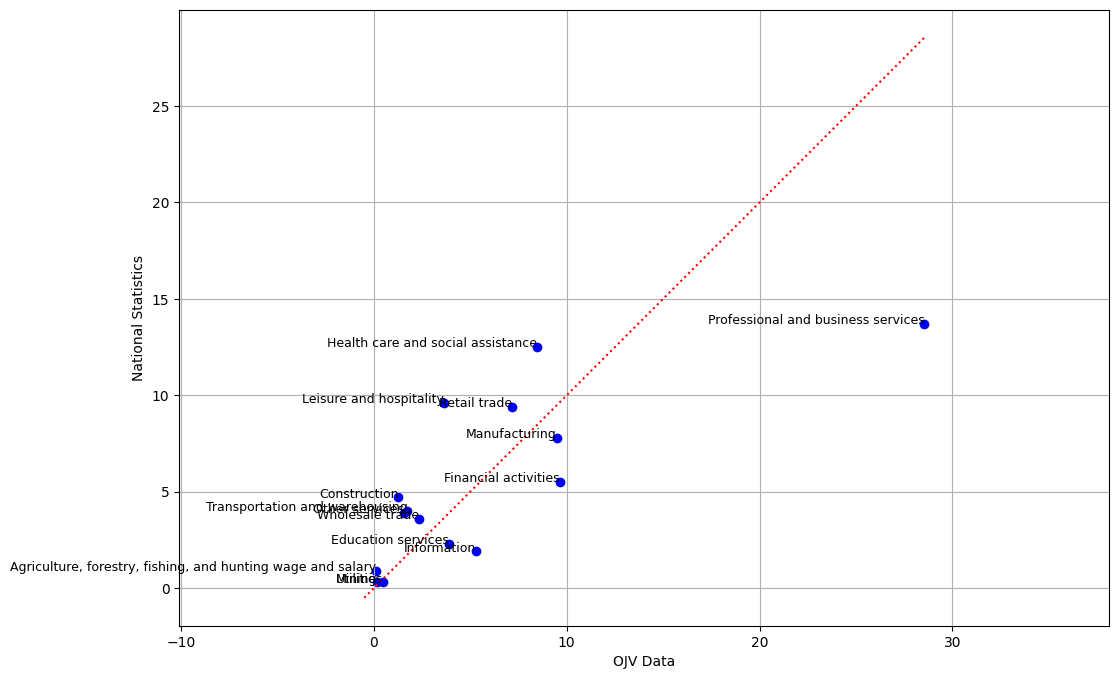

In [41]:
import matplotlib.pyplot as plt

# Filter out rows with missing values in either column
filtered_df = industry_comp.dropna(subset=['OJV Data', 'National Statistics'])

# Create a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(filtered_df['OJV Data'], filtered_df['National Statistics'], color='blue')

# Add labels for each point
for i, row in filtered_df.iterrows():
    plt.text(row['OJV Data'], row['National Statistics'], row['BLS_industry'], fontsize=9, ha='right')

# Set the labels and title
plt.xlabel('OJV Data')
plt.ylabel('National Statistics')
max_val = max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1

plt.plot([-0.5, max_val], [-0.5, max_val], linestyle='dotted', color='red')

# plt.title('Percentage vs National Statistics by BLS Industry')
plt.axis('equal')
# plt.xlim(0, max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1.1)
# plt.ylim(0, max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1.1)

# Show the plot
# Show the plot
plt.grid(True)
# save plot
plt.savefig('../figures/industry_comp_sampleall.png')
plt.show()


## Salary Sample

In [30]:
salary_data_sample = salary_data_sample.merge(industry_crosswalk, left_on = 'NAICS_2022_2', right_on = 'BLS_NAICS', how = 'left')

In [31]:
salary_data_sample.loc[salary_data_sample['BLS_industry'].isna(), 'BLS_industry'] = salary_data_sample.loc[salary_data_sample['BLS_industry'].isna(), 'NAICS_2022_2_NAME']

In [32]:
salary_data_sample.groupby('BLS_industry', dropna=False).size()

BLS_industry
Agriculture, forestry, fishing, and hunting wage and salary      24
Construction                                                    308
Education services                                              841
Financial activities                                           1897
Health care and social assistance                              1136
Information                                                     949
Leisure and hospitality                                         689
Manufacturing                                                  1344
Mining                                                           22
Other services                                                  291
Professional and business services                             6027
Public Administration                                           566
Retail trade                                                   1067
Transportation and warehousing                                  404
Unclassified Industry              

In [34]:
salary_data_sample.to_parquet('../data/salary_sample_body.parquet.gzip', compression='gzip')

In [35]:
grouped_industry_salary = get_grouped_industry(salary_data_sample)

In [36]:
industry_comp_salary = grouped_industry_salary.merge(bls_stats, left_on = 'BLS_industry', right_on = 'Industry name', how = 'outer')

In [37]:
industry_comp_salary = industry_comp_salary[['BLS_industry', 'Industry name','percentage', 'Percent distribution 2022']]

In [38]:
industry_comp_salary.rename(columns = {'percentage': 'OJV Data', 'Percent distribution 2022': 'National Statistics'}, inplace=True)

In [39]:
industry_comp_salary

,BLS_industry,Industry name,OJV Data,National Statistics
0,NaN,"Agriculture, forestry, fishing, and hunting se...",NaN,0.5
1,"Agriculture, forestry, fishing, and hunting wa...","Agriculture, forestry, fishing, and hunting wa...",0.120,0.9
2,Construction,Construction,1.540,4.7
3,Education services,Education services,4.205,2.3
4,NaN,Federal government,NaN,1.7
5,Financial activities,Financial activities,9.485,5.5
6,Health care and social assistance,Health care and social assistance,5.680,12.5
7,Information,Information,4.745,1.9
8,Leisure and hospitality,Leisure and hospitality,3.445,9.6
9,Manufacturing,Manufacturing,6.720,7.8


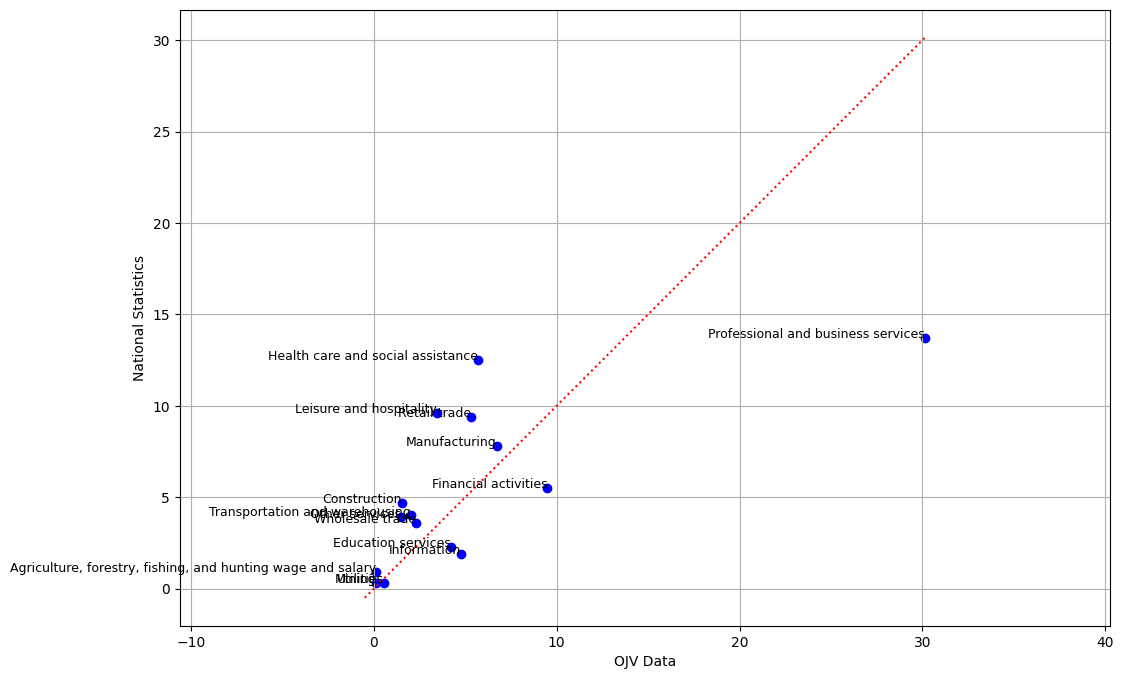

In [42]:
import matplotlib.pyplot as plt

# Filter out rows with missing values in either column
filtered_df_salary = industry_comp_salary.dropna(subset=['OJV Data', 'National Statistics'])

# Create a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(filtered_df_salary['OJV Data'], filtered_df_salary['National Statistics'], color='blue')

# Add labels for each point
for i, row in filtered_df_salary.iterrows():
    plt.text(row['OJV Data'], row['National Statistics'], row['BLS_industry'], fontsize=9, ha='right')

# Set the labels and title
plt.xlabel('OJV Data')
plt.ylabel('National Statistics')
max_val = max(filtered_df_salary['OJV Data'].max(), filtered_df_salary['National Statistics'].max()) * 1

plt.plot([-0.5, max_val], [-0.5, max_val], linestyle='dotted', color='red')

# plt.title('Percentage vs National Statistics by BLS Industry')
plt.axis('equal')
# plt.xlim(0, max(filtered_df_salary['OJV Data'].max(), filtered_df_salary['National Statistics'].max()) * 1.1)
# plt.ylim(0, max(filtered_df_salary['OJV Data'].max(), filtered_df_salary['National Statistics'].max()) * 1.1)

# Show the plot
# Show the plot
plt.grid(True)
# save plot
plt.savefig('../figures/industry_comp_samplesalary.png')
plt.show()
